In [2]:
!pip install tiktoken torch pandas
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch06/01_main-chapter-code/previous_chapters.py
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch06/01_main-chapter-code/gpt_download.py

--2026-03-22 23:59:46--  https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch06/01_main-chapter-code/previous_chapters.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12067 (12K) [text/plain]
Saving to: ‘previous_chapters.py’

previous_chapters.p 100%[===================>]  11.78K  --.-KB/s    in 0s      

2026-03-22 23:59:46 (123 MB/s) - ‘previous_chapters.py’ saved [12067/12067]

--2026-03-22 23:59:46--  https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch06/01_main-chapter-code/gpt_download.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request

# GPT2 Finetuning

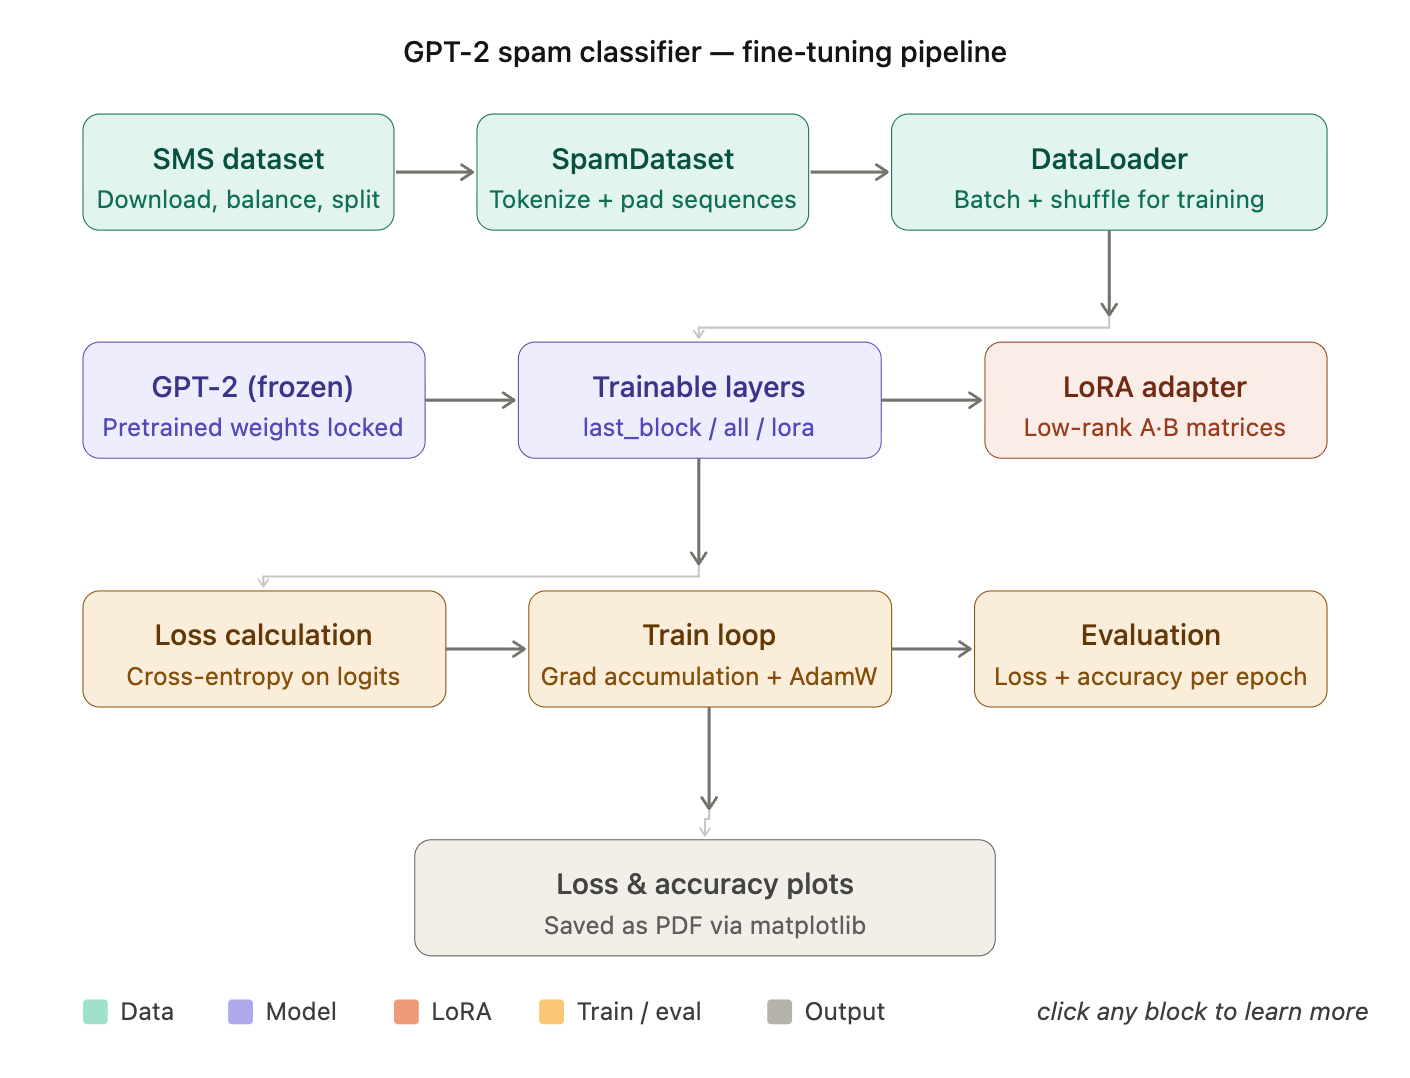

## What is being done

A pre-trained GPT-2 is repurposed as a binary spam classifier (ham=0, spam=1).
The language-model head is swapped for a 2-way Linear, and only a subset of
parameters are trained depending on the chosen strategy.

---

## Three training strategies

| Strategy | What's trainable | Cost |
|---|---|---|
| `all` | Every parameter | highest |
| `last_block` / `last_two_blocks` | Last transformer block(s) + final LayerNorm | middle |
| `lora` | Injected A/B matrices only; everything else frozen | lowest |

All strategies always train the new 2-way output head.

---

## LoRA in one line

Replaces every `nn.Linear` with `W·x + alpha·(A·B)·x`. B is zero-initialised
so the adapter starts as a no-op. Only A and B are trained.

---

## Dataset — SpamDataset

- Downloads the UCI SMS Spam Collection, balances classes (sub-samples ham to
  match spam count), splits 70 / 10 / 20.
- Tokenises with GPT-2 BPE, truncates to `max_length`, pads short sequences
  with token `50256` (`<|endoftext|>`).
- Val/test sets receive the **train set's** `max_length` so all splits are aligned.

---

## Which token feeds the classifier?

GPT-2 outputs one hidden state per token; one must be picked for the head.

| `trainable_token_pos` | Picks |
|---|---|
| `first` (0) | position 0 |
| `last` (-1) | fixed last position |
| `flexible` | last **non-padding** token per sample (recommended) |

`flexible` works by masking pad tokens and summing the mask to find each
sample's true last position.

---

## Training loop — gradient accumulation

Loss is divided by `accumulation_steps` before `.backward()`.
`optimizer.step()` is called only every `accumulation_steps` batches.
Effective batch size = `batch_size × accumulation_steps`.

---

## What to remember

- Freeze all → swap head → selectively unfreeze → train.
- LoRA injects adapters *after* freezing, so only A/B get gradients.
- `flexible` token pos is the safest choice with variable-length sequences.
- Gradient accumulation is just delayed `.step()` with a scaled loss.
- Plots saved as PDFs with dual x-axes: epochs (bottom) and examples seen (top).

Starting training...
Ep 1 (Step 000000): Train loss 0.682, Val loss 0.687
Ep 1 (Step 000050): Train loss 0.385, Val loss 0.385
Ep 1 (Step 000100): Train loss 0.384, Val loss 0.416
Training accuracy: 90.00% | Validation accuracy: 82.50%
Ep 2 (Step 000150): Train loss 0.220, Val loss 0.326
Ep 2 (Step 000200): Train loss 0.251, Val loss 0.288
Ep 2 (Step 000250): Train loss 0.194, Val loss 0.304
Training accuracy: 92.50% | Validation accuracy: 90.00%
Ep 3 (Step 000300): Train loss 0.118, Val loss 0.243
Ep 3 (Step 000350): Train loss 0.176, Val loss 0.259
Training accuracy: 97.50% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.058, Val loss 0.250
Ep 4 (Step 000450): Train loss 0.052, Val loss 0.178
Ep 4 (Step 000500): Train loss 0.078, Val loss 0.170
Training accuracy: 100.00% | Validation accuracy: 92.50%
Ep 5 (Step 000550): Train loss 0.014, Val loss 0.220
Ep 5 (Step 000600): Train loss 0.004, Val loss 0.199
Training accuracy: 100.00% | Validation accuracy: 90.00%


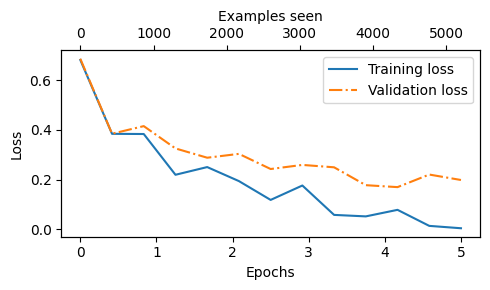

In [3]:
"""
gpt2_lora_finetuning.py
========================
Fine-tunes a pre-trained GPT-2 model for binary spam classification.

Supports three training strategies:
  1. Full fine-tuning  — unfreeze all parameters
  2. Partial fine-tuning — unfreeze only the last transformer block(s)
  3. LoRA fine-tuning  — inject low-rank adapters; most parameters stay frozen

Pipeline overview:
  Dataset download → tokenisation → DataLoader
  → GPT-2 (frozen) + trainable head/adapters
  → training loop with gradient accumulation
  → loss/accuracy plots
"""

import argparse
import math
import os
from pathlib import Path
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
import tiktoken
import torch
from torch.utils.data import DataLoader, Dataset

from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt


# ===========================================================================
# 1. LoRA — Low-Rank Adaptation
# ===========================================================================
# Standard fine-tuning updates every weight in a model, which is expensive for
# large models like GPT-2. LoRA instead *freezes* the original weights and
# injects two small trainable matrices (A and B) beside each Linear layer.
#
# Forward pass with LoRA:
#   output = W·x  +  alpha * (A·B)·x
#            ↑ frozen    ↑ trainable (low-rank)
#
# Because rank << in_dim, the number of new parameters is tiny — often <1% of
# the original model — while still allowing meaningful task adaptation.
# ===========================================================================

class LoRALayer(torch.nn.Module):
    """
    A single LoRA perturbation: two matrices A (in_dim × rank) and B (rank × out_dim).

    The product A·B approximates the weight *update* ΔW without storing the
    full ΔW matrix.  alpha scales the contribution so you can tune the
    effective learning rate independently of the main optimiser LR.
    """

    def __init__(self, in_dim: int, out_dim: int, rank: int, alpha: float):
        super().__init__()

        # A is initialised with Kaiming uniform (same default as nn.Linear).
        # B is initialised to zero so the adapter starts as a no-op — the
        # model behaves identically to the frozen baseline at step 0.
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))

        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
        self.alpha = alpha

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x @ A  maps (batch, in_dim) → (batch, rank)
        # @ B    maps (batch, rank)   → (batch, out_dim)
        # The result is scaled by alpha before being added to the frozen output.
        return self.alpha * (x @ self.A @ self.B)


class LinearWithLoRA(torch.nn.Module):
    """
    Wraps an existing nn.Linear layer with a LoRA adapter.

    The original Linear is kept frozen; only LoRALayer.A and LoRALayer.B are
    trained.  The combined forward is:

        out = linear(x) + lora(x)
    """

    def __init__(self, linear: torch.nn.Linear, rank: int, alpha: float):
        super().__init__()
        self.linear = linear   # frozen original layer
        self.lora = LoRALayer(
            linear.in_features, linear.out_features, rank, alpha
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x) + self.lora(x)


def replace_linear_with_lora(model: torch.nn.Module, rank: int, alpha: float) -> None:
    """
    Recursively walks every submodule and replaces each nn.Linear with a
    LinearWithLoRA wrapper.

    Call *after* freezing the base model parameters so the newly created LoRA
    parameters start with requires_grad=True while the originals stay False.
    """
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            # Swap the Linear with a wrapped version in-place.
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
        else:
            # Recurse into nested submodules (e.g. transformer blocks).
            replace_linear_with_lora(module, rank, alpha)


# ===========================================================================
# 2. Dataset — tokenisation and padding
# ===========================================================================
# GPT-2 uses a fixed context window (1024 tokens).  All sequences in a batch
# must be the same length so PyTorch can stack them into a tensor.
#
# Two strategies are supported:
#   • Padding (default): short sequences are padded to max_length with the
#     <|endoftext|> token (id 50256).  The "flexible" token-position mode
#     masks out padding at inference so it does not affect the classification.
#   • No padding (--no_padding): sequences are truncated to max_length but not
#     padded.  Useful only with batch_size=1 or when all texts happen to be the
#     same length.
# ===========================================================================

class SpamDataset(Dataset):
    """
    Loads a CSV with columns 'Text' (str) and 'Label' (0=ham, 1=spam),
    tokenises every text with the GPT-2 BPE tokeniser, and prepares
    fixed-length integer tensors ready for the DataLoader.

    Args:
        csv_file:     Path to the CSV file.
        tokenizer:    A tiktoken BPE tokeniser instance.
        max_length:   Truncate / pad to this token count.  If None, use the
                      length of the longest sequence in the file.
        pad_token_id: Token id used for padding (default: 50256 = <|endoftext|>).
        no_padding:   If True, skip padding (sequences may have different lengths).
    """

    def __init__(
        self,
        csv_file: str,
        tokenizer,
        max_length: int | None = None,
        pad_token_id: int = 50256,
        no_padding: bool = False,
    ):
        self.data = pd.read_csv(csv_file)

        # If no explicit max_length is given, scan the whole dataset.
        # For val/test sets pass the train set's max_length so they are
        # aligned with the training distribution.
        self.max_length = (
            max_length if max_length is not None
            else self._longest_encoded_length(tokenizer)
        )

        # Tokenise and truncate each text to max_length.
        self.encoded_texts = [
            tokenizer.encode(text)[: self.max_length]
            for text in self.data["Text"]
        ]

        # Pad shorter sequences so every sample has exactly max_length tokens.
        if not no_padding:
            self.encoded_texts = [
                et + [pad_token_id] * (self.max_length - len(et))
                for et in self.encoded_texts
            ]

    def __getitem__(self, index: int):
        """Return (token_ids tensor, label tensor) for one sample."""
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long),
        )

    def __len__(self) -> int:
        return len(self.data)

    def _longest_encoded_length(self, tokenizer) -> int:
        """Scan all texts and return the length of the longest tokenised sequence."""
        return max(len(tokenizer.encode(text)) for text in self.data["Text"])


# ===========================================================================
# 3. Loss and accuracy helpers
# ===========================================================================
# The classification head is a single Linear layer placed on top of GPT-2.
# Because GPT-2 is a causal language model, it produces one hidden state per
# token.  We need to pick *one* of those states to feed into the head.
#
# Three modes (controlled by --trainable_token_pos):
#   "first"    → state at position 0 (BOS)
#   "last"     → state at position -1 (last token, fixed position)
#   "flexible" → state at the last *non-padding* token per sample
#
# "flexible" is the most robust choice when sequences have variable lengths
# because it always reads the token that saw the full context.
# ===========================================================================

def calc_loss_batch(
    input_batch: torch.Tensor,
    target_batch: torch.Tensor,
    model: torch.nn.Module,
    device: torch.device,
    trainable_token_pos=-1,
    ignore_index: int = -100,
    average_embeddings: bool = False,
) -> torch.Tensor:
    """
    Compute the cross-entropy classification loss for one batch.

    Args:
        input_batch:         (batch, seq_len) token id tensor.
        target_batch:        (batch,) label tensor.
        model:               GPT-2 model returning (batch, seq_len, vocab_size).
        device:              Torch device.
        trainable_token_pos: Which token position to use for classification.
                             -1 = last token; 0 = first token; "flexible" =
                             last non-padding token per sample.
        ignore_index:        Label value to ignore in the loss (used for masked
                             positions; -100 is PyTorch's default sentinel).
        average_embeddings:  If True, average all token states instead of
                             selecting a single position.

    Returns:
        Scalar loss tensor.
    """
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    if trainable_token_pos == "flexible":
        # --- Flexible mode: find the last real (non-padding) token per sample ---
        pad_token_id = 50256
        # mask[i, j] = True if token j is NOT padding
        mask = input_batch != pad_token_id
        # Sum True values along seq dimension → index of last real token
        last_token_pos = mask.sum(dim=1) - 1

        logits = model(input_batch)  # (batch, seq_len, vocab_size)
        batch_size = logits.size(0)
        # Gather the logit at the last real position for each sample
        selected_logits = logits[torch.arange(batch_size), last_token_pos]

    else:
        model_output = model(input_batch)  # (batch, seq_len, vocab_size)

        if average_embeddings:
            # Mean-pool across the sequence dimension
            selected_logits = model_output.mean(dim=1)
        else:
            # Pick a fixed position (0 for "first", -1 for "last")
            selected_logits = model_output[:, trainable_token_pos, :]

    return torch.nn.functional.cross_entropy(
        selected_logits, target_batch, ignore_index=ignore_index
    )


def calc_loss_loader(
    data_loader: DataLoader,
    model: torch.nn.Module,
    device: torch.device,
    num_batches: int | None = None,
    trainable_token_pos=-1,
    ignore_index: int = -100,
    average_embeddings: bool = False,
) -> float:
    """
    Average loss over the first `num_batches` batches of a DataLoader.
    If num_batches is None, all batches are used.
    """
    total_loss = 0.0
    num_batches = (
        len(data_loader) if num_batches is None
        else min(num_batches, len(data_loader))
    )

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(
            input_batch, target_batch, model, device,
            trainable_token_pos, ignore_index, average_embeddings,
        )
        total_loss += loss.item()

    return total_loss / num_batches


@torch.no_grad()
def calc_accuracy_loader(
    data_loader: DataLoader,
    model: torch.nn.Module,
    device: torch.device,
    num_batches: int | None = None,
    trainable_token_pos=-1,
    average_embeddings: bool = False,
) -> float:
    """
    Fraction of correct predictions over the first `num_batches` batches.

    Uses @torch.no_grad() to skip gradient computation — evaluation only.
    """
    model.eval()
    correct_predictions, num_examples = 0, 0
    num_batches = (
        len(data_loader) if num_batches is None
        else min(num_batches, len(data_loader))
    )

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break

        input_batch = input_batch.to(device)
        target_batch = target_batch.to(device)

        if trainable_token_pos == "flexible":
            pad_token_id = 50256
            mask = input_batch != pad_token_id
            last_token_pos = mask.sum(dim=1) - 1
            logits = model(input_batch)
            selected_logits = logits[torch.arange(logits.size(0)), last_token_pos]
        else:
            model_output = model(input_batch)
            selected_logits = (
                model_output.mean(dim=1) if average_embeddings
                else model_output[:, trainable_token_pos, :]
            )

        # argmax gives the predicted class (0=ham, 1=spam)
        predicted_labels = torch.argmax(selected_logits, dim=-1)
        num_examples += predicted_labels.shape[0]
        correct_predictions += (predicted_labels == target_batch).sum().item()

    return correct_predictions / num_examples


# ===========================================================================
# 4. Training loop with gradient accumulation
# ===========================================================================
# Gradient accumulation lets you simulate a larger effective batch size when
# GPU memory is limited.  Instead of calling optimizer.step() after every
# batch, we accumulate gradients for `accumulation_steps` batches and then
# update.  The loss is divided by accumulation_steps before .backward() so
# the gradient scale stays consistent regardless of accumulation depth.
# ===========================================================================

def evaluate_model(
    model, train_loader, val_loader, device, eval_iter,
    trainable_token_pos=-1, ignore_index=-100, average_embeddings=False,
):
    """
    Run a quick evaluation pass on a subset of train and val batches.
    Returns (train_loss, val_loss) without modifying model parameters.
    """
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, eval_iter,
            trainable_token_pos, ignore_index, average_embeddings,
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, eval_iter,
            trainable_token_pos, ignore_index, average_embeddings,
        )
    model.train()
    return train_loss, val_loss


def train_classifier_simple(
    model,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    num_epochs: int,
    eval_freq: int,
    eval_iter: int,
    max_steps: int | None = None,
    trainable_token_pos=-1,
    accumulation_steps: int = 1,
    ignore_index: int = -100,
    average_embeddings: bool = False,
):
    """
    Main training loop.

    Args:
        eval_freq:          Evaluate every this many global steps.
        eval_iter:          Number of batches used for each evaluation.
        accumulation_steps: Accumulate gradients over this many batches before
                            calling optimizer.step().  Effective batch size =
                            batch_size * accumulation_steps.

    Returns:
        (train_losses, val_losses, train_accs, val_accs, examples_seen)
    """
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for batch_idx, (input_batch, target_batch) in enumerate(train_loader):

            # --- Forward pass + scaled loss ---
            loss = calc_loss_batch(
                input_batch, target_batch, model, device,
                trainable_token_pos, ignore_index, average_embeddings,
            )

            # Divide loss before backward so accumulated gradients have the
            # same magnitude as a single large-batch pass.
            loss = loss / accumulation_steps
            loss.backward()

            # --- Gradient accumulation gate ---
            # Step the optimiser only on the last accumulation sub-step, or
            # at the end of the epoch (to handle a remainder batch).
            is_update_step = (
                (batch_idx + 1) % accumulation_steps == 0
                or (batch_idx + 1) == len(train_loader)
            )
            if is_update_step:
                optimizer.step()
                optimizer.zero_grad()

            examples_seen += input_batch.shape[0]
            global_step += 1

            # --- Periodic evaluation ---
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter,
                    trainable_token_pos, ignore_index, average_embeddings,
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}"
                )

        # --- Per-epoch accuracy ---
        train_acc = calc_accuracy_loader(
            train_loader, model, device, eval_iter,
            trainable_token_pos, average_embeddings,
        )
        val_acc = calc_accuracy_loader(
            val_loader, model, device, eval_iter,
            trainable_token_pos, average_embeddings,
        )
        print(
            f"Training accuracy: {train_acc * 100:.2f}% | "
            f"Validation accuracy: {val_acc * 100:.2f}%"
        )
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return train_losses, val_losses, train_accs, val_accs, examples_seen


def plot_values(
    epochs_seen,
    examples_seen,
    train_values,
    val_values,
    label: str = "loss",
):
    """
    Save a training-curve plot to `{label}-plot.pdf`.

    Uses a dual x-axis: epochs (bottom) and examples seen (top), so you can
    gauge both convergence speed and data efficiency at a glance.
    """
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Secondary x-axis shows cumulative examples instead of epochs
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)  # invisible — just sets the axis scale
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")


# ===========================================================================
# 5. CLI entry point
# ===========================================================================

if __name__ == "__main__":

    # -----------------------------------------------------------------------
    # 5a. Parse command-line arguments
    # -----------------------------------------------------------------------
    parser = argparse.ArgumentParser(
        description="Fine-tune GPT-2 for spam classification (full, partial, or LoRA)."
    )
    parser.add_argument(
        "--model_size", type=str, default="gpt2-small (124M)",
        help="Which GPT-2 variant to load."
    )
    parser.add_argument(
        "--trainable_layers", type=str, default="last_block",
        help=(
            "Which parts of the model to unfreeze:\n"
            "  'all'             — fine-tune every parameter\n"
            "  'last_block'      — last transformer block + layer norm\n"
            "  'last_two_blocks' — last two blocks + layer norm\n"
            "  'last_layer'      — classification head only\n"
            "  'lora'            — inject LoRA adapters; everything else frozen"
        ),
    )
    parser.add_argument(
        "--trainable_token_pos", type=str, default="last",
        help=(
            "Which token's hidden state feeds the classification head:\n"
            "  'first'    — position 0\n"
            "  'last'     — position -1 (fixed)\n"
            "  'flexible' — last non-padding token (recommended)"
        ),
    )
    parser.add_argument(
        "--average_embeddings", action="store_true", default=False,
        help="Mean-pool all token states instead of picking one position."
    )
    parser.add_argument(
        "--lora_rank", type=int, default=8,
        help="Rank of the LoRA decomposition (lower = fewer parameters)."
    )
    parser.add_argument(
        "--lora_alpha", type=int, default=8,
        help="Scaling factor for the LoRA output."
    )
    parser.add_argument(
        "--no_padding", action="store_true", default=False,
        help="Skip padding (only safe with batch_size=1)."
    )
    parser.add_argument("--num_epochs",       type=int, default=5)
    parser.add_argument("--batch_size",       type=int, default=8)
    parser.add_argument(
        "--accumulation_steps", type=int, default=1,
        help="Gradient accumulation steps.  Effective batch = batch_size × this."
    )
    args = parser.parse_args(args=[])  # Remove args=[] when running from CLI

    # Map human-readable token position to integer index used by PyTorch
    if   args.trainable_token_pos == "first":    args.trainable_token_pos = 0
    elif args.trainable_token_pos == "last":     args.trainable_token_pos = -1
    # "flexible" stays as the string "flexible" and is handled in loss functions

    # -----------------------------------------------------------------------
    # 5b. Build the base GPT-2 model
    # -----------------------------------------------------------------------
    BASE_CONFIG = {
        "vocab_size":     50257,   # GPT-2 BPE vocabulary
        "context_length": 1024,    # Maximum sequence length
        "drop_rate":      0.0,     # Disable dropout during fine-tuning
        "qkv_bias":       True,    # GPT-2 uses bias in QKV projections
        "emb_dim":        768,     # Hidden dimension (gpt2-small)
        "n_layers":       12,      # Transformer blocks
        "n_heads":        12,      # Attention heads
    }
    model = GPTModel(BASE_CONFIG)

    # Freeze every parameter — we will selectively unfreeze below
    for param in model.parameters():
        param.requires_grad = False

    # Replace the language-model head (50257-way) with a 2-way classifier.
    # This new layer starts with requires_grad=True by default.
    model.out_head = torch.nn.Linear(in_features=768, out_features=2)

    # -----------------------------------------------------------------------
    # 5c. Selectively unfreeze layers based on the chosen strategy
    # -----------------------------------------------------------------------
    if args.trainable_layers in ("last_block", "last_two_blocks"):
        # Always unfreeze the last transformer block and final layer norm
        for param in model.trf_blocks[-1].parameters():
            param.requires_grad = True
        for param in model.final_norm.parameters():
            param.requires_grad = True

        if args.trainable_layers == "last_two_blocks":
            for param in model.trf_blocks[-2].parameters():
                param.requires_grad = True

    elif args.trainable_layers == "all":
        for param in model.parameters():
            param.requires_grad = True

    elif args.trainable_layers == "lora":
        # Inject LoRA adapters into every Linear layer.  The base weights stay
        # frozen; only the A and B matrices are trainable.
        replace_linear_with_lora(model, rank=args.lora_rank, alpha=args.lora_alpha)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # -----------------------------------------------------------------------
    # 5d. Download and preprocess the SMS Spam Collection dataset
    # -----------------------------------------------------------------------
    # Source: UCI Machine Learning Repository
    # The dataset is imbalanced (~87% ham).  We balance it by sub-sampling ham
    # to match the number of spam messages, then split 70/10/20.
    url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
    zip_path = "sms_spam_collection.zip"
    extracted_path = "sms_spam_collection"
    data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

    if not data_file_path.exists():
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extracted_path)
        # The archive contains a file without an extension; rename it to .tsv
        os.rename(Path(extracted_path) / "SMSSpamCollection", data_file_path)

    # Load the raw data (tab-separated: label \t message)
    df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])

    # --- Balance classes ---
    # Keep all spam rows, but randomly sample the same number of ham rows.
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    # Convert string labels to integers (ham=0, spam=1)
    balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

    # Shuffle once with a fixed seed for reproducibility
    balanced_df = balanced_df.sample(frac=1, random_state=123).reset_index(drop=True)

    # 70 / 10 / 20 train-val-test split
    train_end = int(len(balanced_df) * 0.7)
    val_end   = train_end + int(len(balanced_df) * 0.1)

    train_df = balanced_df[:train_end]
    val_df   = balanced_df[train_end:val_end]
    test_df  = balanced_df[val_end:]

    train_df.to_csv("train.csv",      index=None)
    val_df.to_csv("validation.csv",   index=None)
    test_df.to_csv("test.csv",        index=None)

    # -----------------------------------------------------------------------
    # 5e. Build datasets and DataLoaders
    # -----------------------------------------------------------------------
    tokenizer = tiktoken.get_encoding("gpt2")

    # Note: val/test datasets receive the train set's max_length so all three
    # splits are padded/truncated to the same sequence length.
    train_dataset = SpamDataset(
        "train.csv", tokenizer, no_padding=args.no_padding
    )
    val_dataset = SpamDataset(
        "validation.csv", tokenizer,
        max_length=train_dataset.max_length,
        no_padding=args.no_padding,
    )
    test_dataset = SpamDataset(
        "test.csv", tokenizer,
        max_length=train_dataset.max_length,
        no_padding=args.no_padding,
    )

    # drop_last=True on the train loader ensures every batch is the same size,
    # which matters for gradient accumulation step counting.
    train_loader = DataLoader(
        train_dataset, batch_size=args.batch_size, shuffle=True, drop_last=True
    )
    val_loader  = DataLoader(val_dataset,  batch_size=args.batch_size, drop_last=False)
    test_loader = DataLoader(test_dataset, batch_size=args.batch_size, drop_last=False)

    # -----------------------------------------------------------------------
    # 5f. Train
    # -----------------------------------------------------------------------
    # AdamW decouples weight decay from the adaptive gradient update, which is
    # important for Transformers.  lr=5e-5 is a conservative starting point for
    # fine-tuning; too high will destroy the pretrained representations.
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

    print("Starting training...")
    train_losses, val_losses, train_accs, val_accs, examples_seen = (
        train_classifier_simple(
            model, train_loader, val_loader, optimizer, device,
            num_epochs=args.num_epochs,
            eval_freq=50,
            eval_iter=5,
            trainable_token_pos=args.trainable_token_pos,
            accumulation_steps=args.accumulation_steps,
            average_embeddings=args.average_embeddings,
        )
    )

    # -----------------------------------------------------------------------
    # 5g. Plot training curves
    # -----------------------------------------------------------------------
    # torch.linspace creates evenly spaced x-axis values for epochs and examples.
    epochs_tensor   = torch.linspace(0, args.num_epochs, len(train_losses))
    examples_tensor = torch.linspace(0, examples_seen,   len(train_losses))

    plot_values(epochs_tensor, examples_tensor, train_losses, val_losses, label="loss")

# GPT 2 Finetuning IMDB

In [1]:
!pip install datasets tiktoken torch pandas
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch06/01_main-chapter-code/previous_chapters.py
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch06/01_main-chapter-code/gpt_download.py

import torch
import pandas as pd
import tiktoken
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from previous_chapters import GPTModel, load_weights_into_gpt

# ==========================================
# 1. Load & Prepare IMDb Dataset
# ==========================================
print("Loading IMDb dataset...")
imdb = load_dataset("imdb")

# We sample a small subset so you can test the training loop quickly in Colab
train_df = pd.DataFrame(imdb['train']).sample(1000, random_state=123).reset_index(drop=True)
val_df = pd.DataFrame(imdb['test']).sample(200, random_state=123).reset_index(drop=True)

class IMDbDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512): # Capped at 512 for Colab RAM
        self.encoded_texts = [tokenizer.encode(text)[:max_length] for text in df["text"]]
        self.encoded_texts = [
            text + [50256] * (max_length - len(text))
            for text in self.encoded_texts
        ]
        self.labels = df["label"].tolist()

    def __getitem__(self, i):
        return torch.tensor(self.encoded_texts[i]), torch.tensor(self.labels[i])

    def __len__(self): return len(self.labels)

tokenizer = tiktoken.get_encoding("gpt2")
train_loader = DataLoader(IMDbDataset(train_df, tokenizer), batch_size=4, shuffle=True)

# ==========================================
# 2. Modify Architecture for IMDb
# ==========================================
BASE_CONFIG = {
    "vocab_size": 50257, "context_length": 1024, "drop_rate": 0.0,
    "qkv_bias": True, "emb_dim": 768, "n_layers": 12, "n_heads": 12
}
model = GPTModel(BASE_CONFIG)

# KEY DIFFERENCE: We train ALL layers for complex datasets!
for param in model.parameters():
    param.requires_grad = True

# Swap the head (768 -> 2 classes: Positive/Negative)
model.out_head = torch.nn.Linear(in_features=768, out_features=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ==========================================
# 3. Training Loop
# ==========================================
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

print("Starting training on IMDb subset...")
for epoch in range(1):
    model.train()
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        # Logits of the LAST output token
        logits = model(inputs)[:, -1, :]

        loss = torch.nn.functional.cross_entropy(logits, targets)
        loss.backward()
        optimizer.step()

        if batch_idx % 25 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx} | Loss: {loss.item():.4f}")

print("Training complete!")

--2026-03-23 02:06:00--  https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch06/01_main-chapter-code/previous_chapters.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12067 (12K) [text/plain]
Saving to: ‘previous_chapters.py’

previous_chapters.p 100%[===================>]  11.78K  --.-KB/s    in 0s      

2026-03-23 02:06:00 (90.8 MB/s) - ‘previous_chapters.py’ saved [12067/12067]

--2026-03-23 02:06:00--  https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch06/01_main-chapter-code/gpt_download.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP reques

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Starting training on IMDb subset...
Epoch 1 | Batch 0 | Loss: 0.8153
Epoch 1 | Batch 25 | Loss: 0.7998
Epoch 1 | Batch 50 | Loss: 0.5887
Epoch 1 | Batch 75 | Loss: 0.6559
Epoch 1 | Batch 100 | Loss: 1.1971
Epoch 1 | Batch 125 | Loss: 0.7532
Epoch 1 | Batch 150 | Loss: 0.9484
Epoch 1 | Batch 175 | Loss: 0.6778
Epoch 1 | Batch 200 | Loss: 0.5675
Epoch 1 | Batch 225 | Loss: 0.7887
Training complete!
